<a href="https://colab.research.google.com/github/pyafv/assets/blob/main/jupyter/getting_started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install **pyafv** in Google Colab

In [10]:
!pip install pyafv

### Have fun!

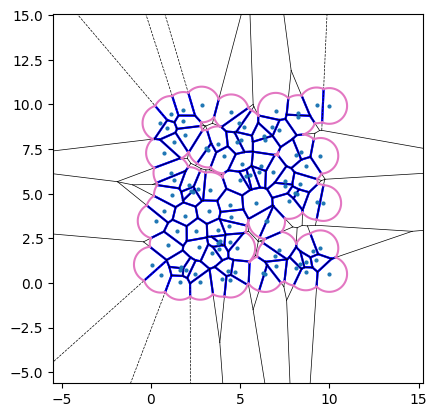

<Axes: >

In [11]:
import numpy as np
import pyafv as afv

N = 100                                          # number of cells
pts = np.random.rand(N, 2) * 10                  # initial positions
params = afv.PhysicalParams(r=1.0)               # use default parameter values
sim = afv.FiniteVoronoiSimulator(pts, params)    # initialize the simulator
sim.plot_2d(show=True)                           # visualize the Voronoi diagram

In [12]:
diag = sim.build()

**Note:**

`diag` is a dictionary containing forces and geometric properties with keys:
- forces: (N,2) array of forces on cell centers
- areas: (N,) array of cell areas
- perimeters: (N,) array of cell perimeters
- vertices: (M,2) array of all Voronoi + extension vertices
- edges_type: List-of-lists of edge types per cell (1=straight, 0=circular arc)
- regions: List-of-lists of vertex indices per cell
- connections: (K,2) array of connected cell index pairs

In [13]:
# diag["forces"]
# diag["areas"]
# diag["perimeters"]
# diag["vertices"]
# diag["edges_type"]
# diag["regions"]
# diag["connections"]

Active dynamics: 100%|██████████| 1000/1000 [00:08<00:00, 120.25it/s]


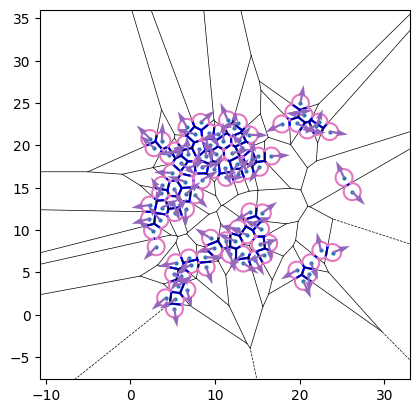

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import pyafv as afv


np.random.seed(42)

N = 100         # number of cells
radius = 1.0    # maximal radius
mu = 1.0        # mobility
v0 = 2.4        # self-propulsion speed
Dr = 0.3        # rotational diffusion constant
dt = 0.01       # time step

# Parameter set
phys = afv.PhysicalParams(
    r=radius,
    A0=np.pi*(radius**2),
    P0=4.8*radius,
    KA=1.0,
    KP=1.0,
    Lambda=0.2
)

# Do not set delta unless you know what you are doing.
# We set it to zero here for comparison with the our primitive results.
phys = phys.replace(delta=0.0)

# Initial positions and orientations
pts = np.random.rand(N, 2)*0.3 + 0.35  # shape (N,2)
pts *= 25.
theta = 2. * np.pi * np.random.rand(N) - np.pi

# Initialize simulator
sim = afv.FiniteVoronoiSimulator(pts, phys)

# Relaxation to mechanical equilibrium
for _ in tqdm.tqdm(range(200), desc="Relaxation"):
    diag = sim.build()
    pts += mu * diag["forces"] * dt
    sim.update_positions(pts)

# Active dynamics
for _ in tqdm.tqdm(range(1000), desc="Active dynamics"):
    diag = sim.build()
    forces = diag["forces"]

    active_velocity = v0 * np.column_stack((np.cos(theta), np.sin(theta)))

    pts += (mu * forces + active_velocity) * dt

    # Gaussian white noise
    theta += np.sqrt(2 * Dr * dt) * np.random.randn(N)

    sim.update_positions(pts)


fig, ax = plt.subplots()
sim.plot_2d(ax=ax)
# Plot cell orientations
ax.quiver(pts[:, 0], pts[:, 1], np.cos(theta),
          np.sin(theta), color='C4', scale=20, zorder=3)
plt.show()

In [ ]:
def custom_plot_2d(pts: np.ndarray, diag: dict, r: float, ax=None):
    """
    Custom plot function
    """
    if ax is None:
        ax = plt.gca()

    point_edges_type = diag["edges_type"]
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]

    # Draw cell centers
    # ax.plot(pts[:, 0], pts[:, 1], 'o', color='C0', markersize=2, zorder=3)

    N = len(pts)

    # Draw each cell boundary
    for idx in range(N):
        edges_type = point_edges_type[idx]
        vertices_f_idx = point_vertices_f_idx[idx]

        x, y = pts[idx]
        if len(edges_type) < 2:
            angle = np.linspace(0, 2*np.pi, 100)
            ax.plot(x + r * np.cos(angle), y + r * np.sin(angle), color="C2", lw=1., zorder=1)
            ax.fill(x + r * np.cos(angle), y + r * np.sin(angle), color="C2", alpha=0.1, zorder=0)
            continue

        for idx_f, edge_type in enumerate(edges_type):
            v1_idx = vertices_f_idx[idx_f]
            x1, y1 = vertices_all[v1_idx]
            idx2 = idx_f + 1 if idx_f < len(edges_type)-1 else 0
            v2_idx = vertices_f_idx[idx2]
            x2, y2 = vertices_all[v2_idx]

            if edge_type == 1:
                ax.plot([x1, x2], [y1, y2], color="C0", lw=1., zorder=2)
                ax.fill([x1, x2, x], [y1, y2, y], 'C2', alpha=0.1, zorder=0)
            else:
                angle1 = np.arctan2(y1-y, x1-x)
                angle2 = np.arctan2(y2-y, x2-x)
                dangle = np.linspace(0, (angle1 - angle2) % (2*np.pi), 100)

                ax.plot(x + r * np.cos(angle2+dangle), y + r * np.sin(angle2+dangle), color="C2", lw=1., zorder=1)
                ax.fill(np.append(x + r * np.cos(angle2+dangle), x), np.append(y + r * np.sin(angle2+dangle), y),
                        color="C2", alpha=0.1, lw=0, zorder=0)

    ax.set_aspect("equal")
    return ax